<a href="https://colab.research.google.com/github/ashwinij-7/Machine-Learning/blob/main/Decision_tree_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [53]:
!pip install pandas numpy scikit-learn

Import dataset


In [54]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nalisha/california-housing-prices-dataset-clean-and-ml")

print("Path to dataset files:", path)

Path to dataset files: /root/.cache/kagglehub/datasets/nalisha/california-housing-prices-dataset-clean-and-ml/versions/1


In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import os

print(os.listdir(path))

['housing.csv.csv']


In [56]:
file_path = os.path.join(path, "housing.csv.csv")

df = pd.read_csv(file_path)

In [57]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


Feature engineering

In [58]:
# Convert categorical columns into numeric columns
df_encoded = pd.get_dummies(df, columns=["ocean_proximity"])

In [59]:
corr_matrix = df_encoded.corr(numeric_only=True)

In [60]:
corr_matrix["median_house_value"].sort_values(ascending=False)

,median_house_value
median_house_value,1.000000
median_income,0.688075
ocean_proximity_<1H OCEAN,0.256617
ocean_proximity_NEAR BAY,0.160284
ocean_proximity_NEAR OCEAN,0.141862
total_rooms,0.134153
housing_median_age,0.105623
households,0.065843
total_bedrooms,0.049686
ocean_proximity_ISLAND,0.023416


Import model

In [61]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor

In [62]:
X = df_encoded[
    [
        'longitude',
        'latitude',
        'housing_median_age',
        'total_rooms',
        'total_bedrooms',
        'population',
        'households',
        'median_income',
        'ocean_proximity_<1H OCEAN',
        'ocean_proximity_INLAND',
        'ocean_proximity_ISLAND',
        'ocean_proximity_NEAR BAY',
        'ocean_proximity_NEAR OCEAN'
    ]
]

y = df_encoded['median_house_value']

train-test split

In [63]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

Train model

In [64]:
from sklearn.model_selection import GridSearchCV

params = {
    "max_depth": [5, 10, 15, 20],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10]
}

grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    params,
    cv=5,
    scoring="r2"
)

grid.fit(X_train, y_train)

print(grid.best_params_)

{'max_depth': 15, 'min_samples_leaf': 10, 'min_samples_split': 2}


In [65]:
model = DecisionTreeRegressor(
    max_depth=15,
    min_samples_leaf=10,
    min_samples_split=2,
    random_state=42
)

In [66]:
model.fit(X_train,y_train)

DecisionTreeRegressor(max_depth=15, min_samples_leaf=10, random_state=42)

Prediction

In [67]:
y_pred = model.predict(X_test)

Evaluate

In [68]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 39161.85592078737
MSE: 3468556426.4306765
RMSE: 58894.45157593945
R2 Score: 0.735737109610477


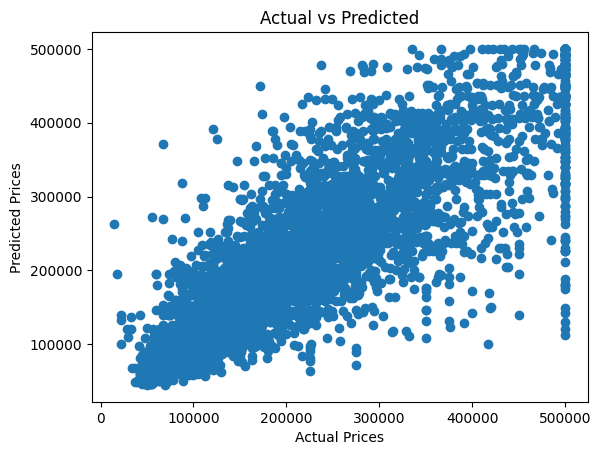

In [69]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted")
plt.show()

In [70]:
train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

print("Train R2:", train_score)
print("Test R2:", test_score)

Train R2: 0.853535957187888
Test R2: 0.735737109610477
